In [1]:
# input_path = './action_clustering_results/251212_ver1_default'
input_path = './action_clustering_results/251215_ver1_default'
output_path = input_path

##### 샘플 데이터

In [2]:
import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [3]:
import glob

pickle_file_path = glob.glob(f'{input_path}/*.pkl')
pickle_file_path

['./action_clustering_results/251215_ver1_default/df_sentiment_score.pkl',
 './action_clustering_results/251215_ver1_default/Actor1_action_cluster.pkl',
 './action_clustering_results/251215_ver1_default/Actor2_action_cluster.pkl',
 './action_clustering_results/251215_ver1_default/Actor0_action_cluster.pkl']

In [4]:
pickle_file_path = pickle_file_path[1:]
pickle_file_path

['./action_clustering_results/251215_ver1_default/Actor1_action_cluster.pkl',
 './action_clustering_results/251215_ver1_default/Actor2_action_cluster.pkl',
 './action_clustering_results/251215_ver1_default/Actor0_action_cluster.pkl']

In [5]:
df = pd.DataFrame()

for p in pickle_file_path :
    with open(p, 'rb') as f:
        new_df = pickle.load(f)
    df = pd.concat([df, new_df])

df = df.reset_index(drop = True)

print(len(df))
df.head()

41338


,src,Date,Date_YYYY,Title,Contents,re_review,tagged_review,vector,cluster,tokenized,action_cluster
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,장보기가 무서워요 체감물가 급등에 소비자 소상공인 한숨 URL 진짜 장보기 무섭네요,"[체감, 물가, 급등, 소비자, 상공인, 한숨, 장보기]","[-0.037731368, 0.21668069, 0.20546217, 0.08354...",1,"[체감, 물가, 급등, 소비자, 상공인, 한숨, 장보기]",3
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",사람은 역시 자기가 경험한 만큼 세상을 보네요 고등3학년 올라가는 딸 기숙생활하는데...,"[사람, 경험, 세상, 고등, 학년, 올라가, 기숙, 생활, 올라오, 고등, 생활,...","[-0.15933605, -0.5519116, 0.77971977, -0.30370...",1,"[사람, 경험, 세상, 고등, 학년, 올라가, 기숙, 생활, 올라오, 고등, 생활,...",2
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,쿠팡 대신 사용할 수 있는 쇼핑몰 추천 추천 받습니다 1 신선제품 새벽배송 마켓컬리...,"[쿠팡, 대신, 사용, 쇼핑몰, 추천, 추천, 신선, 제품, 새벽, 배송, 마켓, ...","[0.070887044, -0.10709982, -0.9592662, 1.49188...",1,"[쿠팡, 대신, 사용, 쇼핑몰, 추천, 추천, 신선, 제품, 새벽, 배송, 마켓, ...",3
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,장보기 쿠팡 식재료 주문 봐주세요 피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이...,"[장보기, 쿠팡, 식재료, 주문, 피곤, 이유, 배달, 시키, 카드, 나오, 건강,...","[-0.749288, 2.328057, -1.223929, 0.2562982, 0....",1,"[장보기, 쿠팡, 식재료, 주문, 피곤, 이유, 배달, 시키, 카드, 나오, 건강,...",1
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,요즘 장보기를 거의 쿠팡과 톡딜에서 해요 최근 몇 달 간 90 이상이 그럴거같아요 ...,"[장보기, 쿠팡, 톡딜, 최근, 이상, 마트, 근처, 홈플, 최근, 행사, 상품, ...","[-1.254588, 0.5734759, 0.09356273, 0.54739547,...",1,"[장보기, 쿠팡, 톡딜, 최근, 이상, 마트, 근처, 홈플, 최근, 행사, 상품, ...",4


# ◆ 1. Satisfaction
* 1.1 감성사전 불러오기 (SentiWord_info.json)
* 1.2 감성점수 구하는 define 함수 만들기
* 1.3 감성점수 구하기
* 1.4 액션 별로 감성점수 계산해서 df에 추가하기

### 1.1 감성사전 불러오기

In [6]:
import json

In [7]:
with open('./SentiWord_info.json', encoding='utf-8-sig', mode='r') as f:
    sent_dicts = json.load(f)

### 1.2 감성점수 구하는 함수 만들기

In [8]:
len(sent_dicts)

14854

In [9]:
sent_dicts[0:10]

[{'word': '(-;', 'word_root': '(', 'polarity': '1'},
 {'word': '(;_;)', 'word_root': '(;_;)', 'polarity': '-1'},
 {'word': '(^^)', 'word_root': '(^^)', 'polarity': '1'},
 {'word': '(^-^)', 'word_root': '(^-^)', 'polarity': '1'},
 {'word': '(^^*', 'word_root': '(', 'polarity': '1'},
 {'word': '(^_^)', 'word_root': '(^_^)', 'polarity': '1'},
 {'word': '(^_^;', 'word_root': '(', 'polarity': '-1'},
 {'word': '(^o^)', 'word_root': '(^o^)', 'polarity': '1'},
 {'word': '(-_-)', 'word_root': '(-_-)', 'polarity': '-1'},
 {'word': '(T_T)', 'word_root': '(T_T)', 'polarity': '-1'}]

In [10]:
sent_dicts[100:110]

[{'word': '가량맞고', 'word_root': '가량', 'polarity': '-1'},
 {'word': '가량맞고 야살스러운', 'word_root': '가량 야살', 'polarity': '-1'},
 {'word': '가량맞고 야살스러움', 'word_root': '가량 야살', 'polarity': '-1'},
 {'word': '가려서 좋아하다', 'word_root': '가리 좋아하', 'polarity': '-1'},
 {'word': '가려운', 'word_root': '가렵', 'polarity': '-1'},
 {'word': '가려운 느낌이', 'word_root': '가렵 느낌', 'polarity': '-1'},
 {'word': '가려운 증상을', 'word_root': '가렵 증상', 'polarity': '-1'},
 {'word': '가련하게', 'word_root': '가련', 'polarity': '-1'},
 {'word': '가련하게 여기다', 'word_root': '가련 여기', 'polarity': '-1'},
 {'word': '가련하게 여김', 'word_root': '가련 여기', 'polarity': '-1'}]

In [11]:
sent_df = pd.DataFrame(sent_dicts)
sent_df['polarity'].value_counts()

polarity
-1    5030
-2    4799
2     2602
1     2269
0      154
Name: count, dtype: int64

In [12]:
sent_df

,word,word_root,polarity
0,(-;,(,1
1,(;_;),(;_;),-1
2,(^^),(^^),1
3,(^-^),(^-^),1
4,(^^*,(,1
...,...,...,...
14849,반신반의하다,반신반의,0
14850,신비롭다,신비,1
14851,아리송하다,아리송,-1
14852,알쏭하다,알쏭하,-1


In [13]:
def sentiment_score(sent_dicts, token_list) :
    result_list = []

    for token in token_list :
        for s in sent_dicts :
            if s['word'] == token :
                result = s['word'], s['polarity']
                result_list.append(result)
    return result_list

In [14]:
df['tokenized'][1]

['사람',
 '경험',
 '세상',
 '고등',
 '학년',
 '올라가',
 '기숙',
 '생활',
 '올라오',
 '고등',
 '생활',
 '힘들',
 '생각',
 '첫아이',
 '모르',
 '보내',
 '고등',
 '생활',
 '힘들',
 '모르',
 '기숙',
 '학원',
 '다니',
 '인강',
 '엄마',
 '만나',
 '엄마',
 '고등',
 '학년',
 '올라가',
 '아들',
 '누나',
 '따르',
 '기숙',
 '사람',
 '경험',
 '생각나',
 '아이',
 '뒷바라지',
 '경제',
 '경제',
 '건강',
 '여건',
 '허락',
 '대단하',
 '마중',
 '나가',
 '고속',
 '버스',
 '그때',
 '집안일',
 '장보기',
 '돌아가',
 '마음']

In [15]:
sentiment_score(sent_dicts, df['tokenized'][1])

[('힘들', '-2'), ('힘들', '-2')]

### 1.3  감성점수 구하기

#### 1.3.1 적합하게 형태소 재분리

In [16]:
# !pip install kiwipiepy
# !pip install konlpy

In [17]:
from konlpy.tag import Okt
okt=Okt()

from kiwipiepy import Kiwi
kiwi = Kiwi()

In [18]:
def okt_pos_tagging(string) :
    string = kiwi.space(string)
    pos_words = okt.morphs(string, stem=True, norm = True)
    return pos_words

#### 1.3.2 감정점수 적용하기

In [19]:
df.head()

,src,Date,Date_YYYY,Title,Contents,re_review,tagged_review,vector,cluster,tokenized,action_cluster
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,장보기가 무서워요 체감물가 급등에 소비자 소상공인 한숨 URL 진짜 장보기 무섭네요,"[체감, 물가, 급등, 소비자, 상공인, 한숨, 장보기]","[-0.037731368, 0.21668069, 0.20546217, 0.08354...",1,"[체감, 물가, 급등, 소비자, 상공인, 한숨, 장보기]",3
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",사람은 역시 자기가 경험한 만큼 세상을 보네요 고등3학년 올라가는 딸 기숙생활하는데...,"[사람, 경험, 세상, 고등, 학년, 올라가, 기숙, 생활, 올라오, 고등, 생활,...","[-0.15933605, -0.5519116, 0.77971977, -0.30370...",1,"[사람, 경험, 세상, 고등, 학년, 올라가, 기숙, 생활, 올라오, 고등, 생활,...",2
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,쿠팡 대신 사용할 수 있는 쇼핑몰 추천 추천 받습니다 1 신선제품 새벽배송 마켓컬리...,"[쿠팡, 대신, 사용, 쇼핑몰, 추천, 추천, 신선, 제품, 새벽, 배송, 마켓, ...","[0.070887044, -0.10709982, -0.9592662, 1.49188...",1,"[쿠팡, 대신, 사용, 쇼핑몰, 추천, 추천, 신선, 제품, 새벽, 배송, 마켓, ...",3
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,장보기 쿠팡 식재료 주문 봐주세요 피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이...,"[장보기, 쿠팡, 식재료, 주문, 피곤, 이유, 배달, 시키, 카드, 나오, 건강,...","[-0.749288, 2.328057, -1.223929, 0.2562982, 0....",1,"[장보기, 쿠팡, 식재료, 주문, 피곤, 이유, 배달, 시키, 카드, 나오, 건강,...",1
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,요즘 장보기를 거의 쿠팡과 톡딜에서 해요 최근 몇 달 간 90 이상이 그럴거같아요 ...,"[장보기, 쿠팡, 톡딜, 최근, 이상, 마트, 근처, 홈플, 최근, 행사, 상품, ...","[-1.254588, 0.5734759, 0.09356273, 0.54739547,...",1,"[장보기, 쿠팡, 톡딜, 최근, 이상, 마트, 근처, 홈플, 최근, 행사, 상품, ...",4


In [20]:
sentiment = []

for token in tqdm(df['tokenized']) :
    score = sentiment_score(sent_dicts, token)
    sentiment.append(score)

100%|██████████| 41338/41338 [32:13<00:00, 21.38it/s]  


In [21]:
sentiment[0]

[('한숨', '-1')]

In [22]:
sum([int(i[1]) for i in sentiment[0]])

-1

In [23]:
avg_sents = []

for sents in tqdm(sentiment) :
    sents_score = sum([int(i[1]) for i in sents])
    avg_sents.append(sents_score)

100%|██████████| 41338/41338 [00:00<00:00, 984348.55it/s]


In [24]:
df['sentiment_score'] = avg_sents
df.head()

,src,Date,Date_YYYY,Title,Contents,re_review,tagged_review,vector,cluster,tokenized,action_cluster,sentiment_score
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,장보기가 무서워요 체감물가 급등에 소비자 소상공인 한숨 URL 진짜 장보기 무섭네요,"[체감, 물가, 급등, 소비자, 상공인, 한숨, 장보기]","[-0.037731368, 0.21668069, 0.20546217, 0.08354...",1,"[체감, 물가, 급등, 소비자, 상공인, 한숨, 장보기]",3,-1
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",사람은 역시 자기가 경험한 만큼 세상을 보네요 고등3학년 올라가는 딸 기숙생활하는데...,"[사람, 경험, 세상, 고등, 학년, 올라가, 기숙, 생활, 올라오, 고등, 생활,...","[-0.15933605, -0.5519116, 0.77971977, -0.30370...",1,"[사람, 경험, 세상, 고등, 학년, 올라가, 기숙, 생활, 올라오, 고등, 생활,...",2,-4
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,쿠팡 대신 사용할 수 있는 쇼핑몰 추천 추천 받습니다 1 신선제품 새벽배송 마켓컬리...,"[쿠팡, 대신, 사용, 쇼핑몰, 추천, 추천, 신선, 제품, 새벽, 배송, 마켓, ...","[0.070887044, -0.10709982, -0.9592662, 1.49188...",1,"[쿠팡, 대신, 사용, 쇼핑몰, 추천, 추천, 신선, 제품, 새벽, 배송, 마켓, ...",3,3
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,장보기 쿠팡 식재료 주문 봐주세요 피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이...,"[장보기, 쿠팡, 식재료, 주문, 피곤, 이유, 배달, 시키, 카드, 나오, 건강,...","[-0.749288, 2.328057, -1.223929, 0.2562982, 0....",1,"[장보기, 쿠팡, 식재료, 주문, 피곤, 이유, 배달, 시키, 카드, 나오, 건강,...",1,0
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,요즘 장보기를 거의 쿠팡과 톡딜에서 해요 최근 몇 달 간 90 이상이 그럴거같아요 ...,"[장보기, 쿠팡, 톡딜, 최근, 이상, 마트, 근처, 홈플, 최근, 행사, 상품, ...","[-1.254588, 0.5734759, 0.09356273, 0.54739547,...",1,"[장보기, 쿠팡, 톡딜, 최근, 이상, 마트, 근처, 홈플, 최근, 행사, 상품, ...",4,0


In [25]:
# csv 저장
df.to_csv(f'{output_path}/df_sentiment_score.csv', encoding='utf-8-sig')

# pkl 저장
with open (f'{output_path}/df_sentiment_score.pkl', 'wb') as f:
    pickle.dump(df, f)

### 1.4 전체 액터와 액션에 대해서 감성점수 계산


#### 1.4.1 dict 형식으로 출력


In [26]:
df['cluster'].value_counts()

cluster
1    32169
0     7638
2     1531
Name: count, dtype: int64

In [27]:
df['action_cluster'].value_counts()

action_cluster
1    15497
2    11499
4     9161
3     5181
Name: count, dtype: int64

In [28]:
sent_dict = dict()

for actor in df['cluster'].unique() :
    actor_df = df[df['cluster'] == actor]

    for action in actor_df['action_cluster'].unique() :
        action_scores = actor_df[actor_df['action_cluster'] == action]['sentiment_score'] # 해당 action에 해당하는 sentiment_score만 추출
        action_score = np.mean(action_scores) # 평균
        sent_dict[f'Actor{actor}_Action{action}'] = action_score

In [29]:
sent_dict

{'Actor1_Action3': 1.3692681445490433,
 'Actor1_Action2': -0.22663522402879482,
 'Actor1_Action1': 1.5778006519128496,
 'Actor1_Action4': -0.09562274860823054,
 'Actor2_Action3': 6.447941888619854,
 'Actor2_Action2': 14.66,
 'Actor2_Action1': 16.79940119760479,
 'Actor0_Action2': 3.492312834224599,
 'Actor0_Action1': 4.942604856512141,
 'Actor0_Action3': -3.1966101694915254}

#### 1.4.2 정규화 (-10~10)
* minmaxscaler를 이용해서 정규화 : 주어진 데이터를 특정 범위로 변환(정규화)하는 데 사용
* minmaxscaler은 배열(array 데이터 형식, shape이 1이어야 작동)로 변환필요 

In [30]:
from sklearn.preprocessing import MinMaxScaler

In [31]:
sent_dict.values()

dict_values([1.3692681445490433, -0.22663522402879482, 1.5778006519128496, -0.09562274860823054, 6.447941888619854, 14.66, 16.79940119760479, 3.492312834224599, 4.942604856512141, -3.1966101694915254])

In [32]:
data = sent_dict.values()
data = np.array(list(data)).reshape(-1,1) # shape 변환 -> (?, 1)
data

array([[ 1.36926814],
       [-0.22663522],
       [ 1.57780065],
       [-0.09562275],
       [ 6.44794189],
       [14.66      ],
       [16.7994012 ],
       [ 3.49231283],
       [ 4.94260486],
       [-3.19661017]])

In [33]:
scaler = MinMaxScaler(feature_range=(-10,10))
transformed_data = scaler.fit_transform(data)
transformed_data

array([[ -5.43321092],
       [ -7.02943263],
       [ -5.22463682],
       [ -6.89839402],
       [ -0.35352413],
       [  7.86017205],
       [ 10.        ],
       [ -3.30974275],
       [ -1.85916143],
       [-10.        ]])

In [34]:
transformed_data.flatten().tolist()

[-5.433210923700736,
 -7.0294326293994205,
 -5.224636820060298,
 -6.898394020733547,
 -0.35352412933550426,
 7.860172052987325,
 9.999999999999998,
 -3.3097427472732592,
 -1.8591614331677713,
 -10.0]

In [35]:
score_result = transformed_data.flatten().tolist()
score_result =[round(i,4) for i in score_result]
score_result

[-5.4332,
 -7.0294,
 -5.2246,
 -6.8984,
 -0.3535,
 7.8602,
 10.0,
 -3.3097,
 -1.8592,
 -10.0]

In [36]:
for key, new_value in zip(sent_dict.keys(), score_result) :
    sent_dict[key] = new_value
sent_dict

{'Actor1_Action3': -5.4332,
 'Actor1_Action2': -7.0294,
 'Actor1_Action1': -5.2246,
 'Actor1_Action4': -6.8984,
 'Actor2_Action3': -0.3535,
 'Actor2_Action2': 7.8602,
 'Actor2_Action1': 10.0,
 'Actor0_Action2': -3.3097,
 'Actor0_Action1': -1.8592,
 'Actor0_Action3': -10.0}

In [37]:
sent_dict.items()

dict_items([('Actor1_Action3', -5.4332), ('Actor1_Action2', -7.0294), ('Actor1_Action1', -5.2246), ('Actor1_Action4', -6.8984), ('Actor2_Action3', -0.3535), ('Actor2_Action2', 7.8602), ('Actor2_Action1', 10.0), ('Actor0_Action2', -3.3097), ('Actor0_Action1', -1.8592), ('Actor0_Action3', -10.0)])

In [38]:
sents_df = pd.DataFrame(sent_dict.items(), columns=['Action', 'satisfaction'])
sents_df

,Action,satisfaction
0,Actor1_Action3,-5.4332
1,Actor1_Action2,-7.0294
2,Actor1_Action1,-5.2246
3,Actor1_Action4,-6.8984
4,Actor2_Action3,-0.3535
5,Actor2_Action2,7.8602
6,Actor2_Action1,10.0000
7,Actor0_Action2,-3.3097
8,Actor0_Action1,-1.8592
9,Actor0_Action3,-10.0000


In [39]:
data = data.flatten().tolist()
data =[round(i,4) for i in data]

sents_df['satisfaction_real'] = data
sents_df

,Action,satisfaction,satisfaction_real
0,Actor1_Action3,-5.4332,1.3693
1,Actor1_Action2,-7.0294,-0.2266
2,Actor1_Action1,-5.2246,1.5778
3,Actor1_Action4,-6.8984,-0.0956
4,Actor2_Action3,-0.3535,6.4479
5,Actor2_Action2,7.8602,14.6600
6,Actor2_Action1,10.0000,16.7994
7,Actor0_Action2,-3.3097,3.4923
8,Actor0_Action1,-1.8592,4.9426
9,Actor0_Action3,-10.0000,-3.1966


# ◆ 2. Importance
* 2.1 importance 점수 구하기 _ 전체 토픽의 비중
* 2.2 importance 점수 정규화

### 2-1. Importance 점수 구하기

In [40]:
from collections import Counter

In [41]:
importance_check = []

for actor, action in zip(df['cluster'], df['action_cluster']):
    importance_check.append('Actor'+ str(actor)+'_'+'Action'+str(action))
    
importance_check

['Actor1_Action3',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action1',
 'Actor1_Action4',
 'Actor1_Action3',
 'Actor1_Action1',
 'Actor1_Action2',
 'Actor1_Action4',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action2',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action2',
 'Actor1_Action1',
 'Actor1_Action2',
 'Actor1_Action2',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action1',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action1',
 'Actor1_Action3',
 'Actor1_Action2',
 'Actor1_Action1',
 'Actor1_Action2',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action3',
 'Actor1_Action1',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action1',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action2',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action2',
 'Actor1_Action1',
 'Actor1_Action2',
 'Actor1_Action3',
 'Actor1_Action3',
 'Actor1_Action3',
 'Actor1_Action2',
 'Actor1_Action1',
 'Actor1_Action1',
 'Actor1_Action1',
 'Actor1_Action2',
 'Actor1_Action1',
 'Actor1_Act

In [42]:
frequency = Counter(importance_check)
frequency

Counter({'Actor1_Action1': 11658,
         'Actor1_Action4': 9161,
         'Actor1_Action2': 8057,
         'Actor1_Action3': 3293,
         'Actor0_Action1': 3171,
         'Actor0_Action2': 2992,
         'Actor0_Action3': 1475,
         'Actor2_Action1': 668,
         'Actor2_Action2': 450,
         'Actor2_Action3': 413})

In [43]:
importance_dict = dict()

total_count = sum(frequency.values())

for item, value in frequency.items() :
    importance = (value / total_count) * 100 # 퍼센티지
    importance_dict[item] = importance

importance_dict

{'Actor1_Action3': 7.966036092699211,
 'Actor1_Action2': 19.49054139048817,
 'Actor1_Action1': 28.201654651894142,
 'Actor1_Action4': 22.161207605592917,
 'Actor2_Action3': 0.9990807489476995,
 'Actor2_Action2': 1.0885867724611737,
 'Actor2_Action1': 1.615946586675698,
 'Actor0_Action2': 7.237892496008515,
 'Actor0_Action1': 7.670908123276404,
 'Actor0_Action3': 3.5681455319560698}

### 2-2. Importance 점수 정규화(0~10)

In [44]:
data = importance_dict.values()
data = np.array(list(data)).reshape(-1,1) # 정규화를 위한 reshape
data

array([[ 7.96603609],
       [19.49054139],
       [28.20165465],
       [22.16120761],
       [ 0.99908075],
       [ 1.08858677],
       [ 1.61594659],
       [ 7.2378925 ],
       [ 7.67090812],
       [ 3.56814553]])

In [45]:
scaler = MinMaxScaler(feature_range=(0,10))
transformed_data = scaler.fit_transform(data)
transformed_data

array([[ 2.56113828],
       [ 6.79768786],
       [10.        ],
       [ 7.77945754],
       [ 0.        ],
       [ 0.03290351],
       [ 0.22676745],
       [ 2.29346376],
       [ 2.45264562],
       [ 0.94441974]])

In [46]:
score_result = transformed_data.flatten().tolist()
score_result = [round(i,4) for i in score_result]
score_result

[2.5611, 6.7977, 10.0, 7.7795, 0.0, 0.0329, 0.2268, 2.2935, 2.4526, 0.9444]

In [47]:
for key, new_value in zip(importance_dict.keys(), score_result) :
    importance_dict[key] = new_value
    
importance_dict # 0~10 정규화된 값으로 업데이트

{'Actor1_Action3': 2.5611,
 'Actor1_Action2': 6.7977,
 'Actor1_Action1': 10.0,
 'Actor1_Action4': 7.7795,
 'Actor2_Action3': 0.0,
 'Actor2_Action2': 0.0329,
 'Actor2_Action1': 0.2268,
 'Actor0_Action2': 2.2935,
 'Actor0_Action1': 2.4526,
 'Actor0_Action3': 0.9444}

In [48]:
sents_df

,Action,satisfaction,satisfaction_real
0,Actor1_Action3,-5.4332,1.3693
1,Actor1_Action2,-7.0294,-0.2266
2,Actor1_Action1,-5.2246,1.5778
3,Actor1_Action4,-6.8984,-0.0956
4,Actor2_Action3,-0.3535,6.4479
5,Actor2_Action2,7.8602,14.6600
6,Actor2_Action1,10.0000,16.7994
7,Actor0_Action2,-3.3097,3.4923
8,Actor0_Action1,-1.8592,4.9426
9,Actor0_Action3,-10.0000,-3.1966


In [49]:
importance_list = []

for action in sents_df['Action']:
    importance_list.append(importance_dict[action])

importance_list

[2.5611, 6.7977, 10.0, 7.7795, 0.0, 0.0329, 0.2268, 2.2935, 2.4526, 0.9444]

In [50]:
sents_df['importance'] = importance_list
sents_df

,Action,satisfaction,satisfaction_real,importance
0,Actor1_Action3,-5.4332,1.3693,2.5611
1,Actor1_Action2,-7.0294,-0.2266,6.7977
2,Actor1_Action1,-5.2246,1.5778,10.0000
3,Actor1_Action4,-6.8984,-0.0956,7.7795
4,Actor2_Action3,-0.3535,6.4479,0.0000
5,Actor2_Action2,7.8602,14.6600,0.0329
6,Actor2_Action1,10.0000,16.7994,0.2268
7,Actor0_Action2,-3.3097,3.4923,2.2935
8,Actor0_Action1,-1.8592,4.9426,2.4526
9,Actor0_Action3,-10.0000,-3.1966,0.9444


In [51]:
data = data.flatten().tolist()
data =[round(i,4) for i in data]

sents_df['importance_real'] = data
sents_df

,Action,satisfaction,satisfaction_real,importance,importance_real
0,Actor1_Action3,-5.4332,1.3693,2.5611,7.9660
1,Actor1_Action2,-7.0294,-0.2266,6.7977,19.4905
2,Actor1_Action1,-5.2246,1.5778,10.0000,28.2017
3,Actor1_Action4,-6.8984,-0.0956,7.7795,22.1612
4,Actor2_Action3,-0.3535,6.4479,0.0000,0.9991
5,Actor2_Action2,7.8602,14.6600,0.0329,1.0886
6,Actor2_Action1,10.0000,16.7994,0.2268,1.6159
7,Actor0_Action2,-3.3097,3.4923,2.2935,7.2379
8,Actor0_Action1,-1.8592,4.9426,2.4526,7.6709
9,Actor0_Action3,-10.0000,-3.1966,0.9444,3.5681


# ◆ 3. Opportunity
* 3.1 Opportunity score
* 3.2 Opportunity area

### 3.1 Opportunity score
Opportunity = Importance + Max(Importance-Satisfaction, 0)

In [52]:
def Opportunity_score(satisfaction, importance) :
    result = importance + max(importance - satisfaction, 0)
    return result

In [53]:
sents_df

,Action,satisfaction,satisfaction_real,importance,importance_real
0,Actor1_Action3,-5.4332,1.3693,2.5611,7.9660
1,Actor1_Action2,-7.0294,-0.2266,6.7977,19.4905
2,Actor1_Action1,-5.2246,1.5778,10.0000,28.2017
3,Actor1_Action4,-6.8984,-0.0956,7.7795,22.1612
4,Actor2_Action3,-0.3535,6.4479,0.0000,0.9991
5,Actor2_Action2,7.8602,14.6600,0.0329,1.0886
6,Actor2_Action1,10.0000,16.7994,0.2268,1.6159
7,Actor0_Action2,-3.3097,3.4923,2.2935,7.2379
8,Actor0_Action1,-1.8592,4.9426,2.4526,7.6709
9,Actor0_Action3,-10.0000,-3.1966,0.9444,3.5681


In [54]:
opportunity_list = []

for i, j in zip(sents_df['satisfaction'], sents_df['importance']) :
    score_result = Opportunity_score(i, j)
    opportunity_list.append(score_result)

sents_df['opportunity_score'] = opportunity_list

sents_df

,Action,satisfaction,satisfaction_real,importance,importance_real,opportunity_score
0,Actor1_Action3,-5.4332,1.3693,2.5611,7.9660,10.5554
1,Actor1_Action2,-7.0294,-0.2266,6.7977,19.4905,20.6248
2,Actor1_Action1,-5.2246,1.5778,10.0000,28.2017,25.2246
3,Actor1_Action4,-6.8984,-0.0956,7.7795,22.1612,22.4574
4,Actor2_Action3,-0.3535,6.4479,0.0000,0.9991,0.3535
5,Actor2_Action2,7.8602,14.6600,0.0329,1.0886,0.0329
6,Actor2_Action1,10.0000,16.7994,0.2268,1.6159,0.2268
7,Actor0_Action2,-3.3097,3.4923,2.2935,7.2379,7.8967
8,Actor0_Action1,-1.8592,4.9426,2.4526,7.6709,6.7644
9,Actor0_Action3,-10.0000,-3.1966,0.9444,3.5681,11.8888


In [55]:
sents_df.to_csv(f'{output_path}/OpportunityScore.csv', encoding='utf-8-sig')

### 3.2 Opportunity area

In [56]:
# !pip install adjustText

In [57]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [58]:
sents_df

,Action,satisfaction,satisfaction_real,importance,importance_real,opportunity_score
0,Actor1_Action3,-5.4332,1.3693,2.5611,7.9660,10.5554
1,Actor1_Action2,-7.0294,-0.2266,6.7977,19.4905,20.6248
2,Actor1_Action1,-5.2246,1.5778,10.0000,28.2017,25.2246
3,Actor1_Action4,-6.8984,-0.0956,7.7795,22.1612,22.4574
4,Actor2_Action3,-0.3535,6.4479,0.0000,0.9991,0.3535
5,Actor2_Action2,7.8602,14.6600,0.0329,1.0886,0.0329
6,Actor2_Action1,10.0000,16.7994,0.2268,1.6159,0.2268
7,Actor0_Action2,-3.3097,3.4923,2.2935,7.2379,7.8967
8,Actor0_Action1,-1.8592,4.9426,2.4526,7.6709,6.7644
9,Actor0_Action3,-10.0000,-3.1966,0.9444,3.5681,11.8888


In [59]:
actions = sents_df['Action'] #action -> actions
colors = np.random.rand(len(actions), 3)  #action -> actions (8x3); 3->RGB
importance = sents_df['importance']
satisfaction = sents_df['satisfaction']

In [60]:
# satisfaction.mean()
importance.mean()

3.3088500000000005

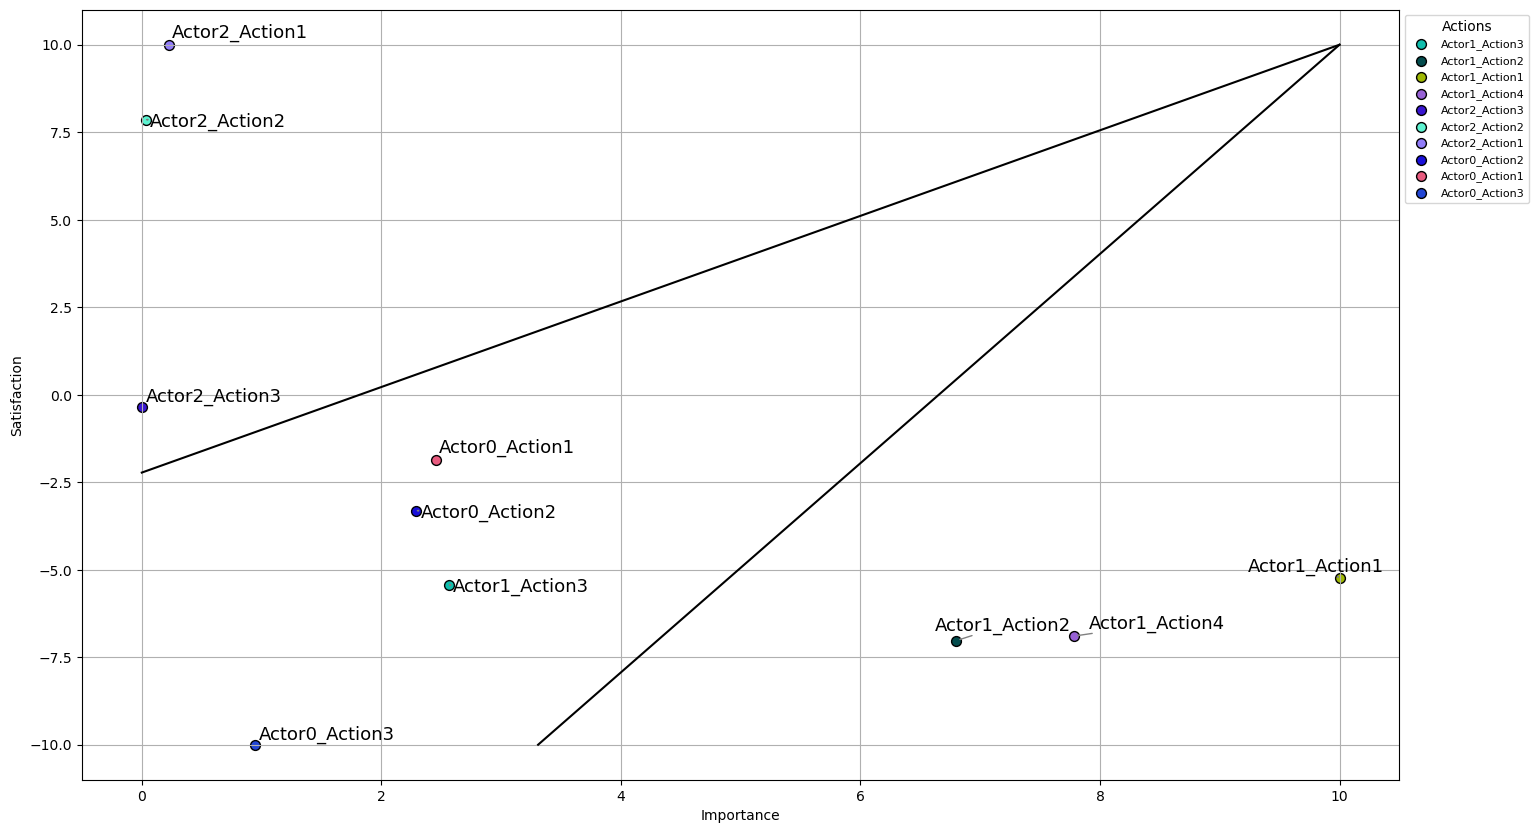

In [61]:
plt.figure(figsize = (17,10))

for i, action in enumerate(actions) :  #action -> actions
    plt.scatter(importance[i], satisfaction[i], c=[colors[i]], label = action, s = 50, edgecolors = 'black') #edgecolor -> edgecolors

# 범례
plt.legend(title='Actions', fontsize=8, title_fontsize = 10, loc='best', bbox_to_anchor=(1,1))

plt.xlabel('Importance')
plt.ylabel('Satisfaction')

#만족도 기준선
xdata = [0,10] # 0 ~ 10
ydata = [satisfaction.mean(), 10] # 1.79 ~ 10
plt.plot(xdata, ydata, 'k-')

#중요도 기준선
x_data = [importance.mean(), 10] # 3.13 ~ 10
y_data = [-10, 10]
plt.plot(x_data, y_data, 'k-')

# 각 포인트에 레이블(액션) 추가
texts = []

for i, action in enumerate(actions) :   #action -> actions
    texts.append(plt.text(importance[i], satisfaction[i], action, fontsize=13, ha='left')) # (x, y, text)

# 텍스트가 겹치지 않게 위치를 조정
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey', lw=1))

plt.grid(True)

plt.savefig(f'{output_path}/OpportunityArea.png', dpi=300, bbox_inches = 'tight')

plt.show()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


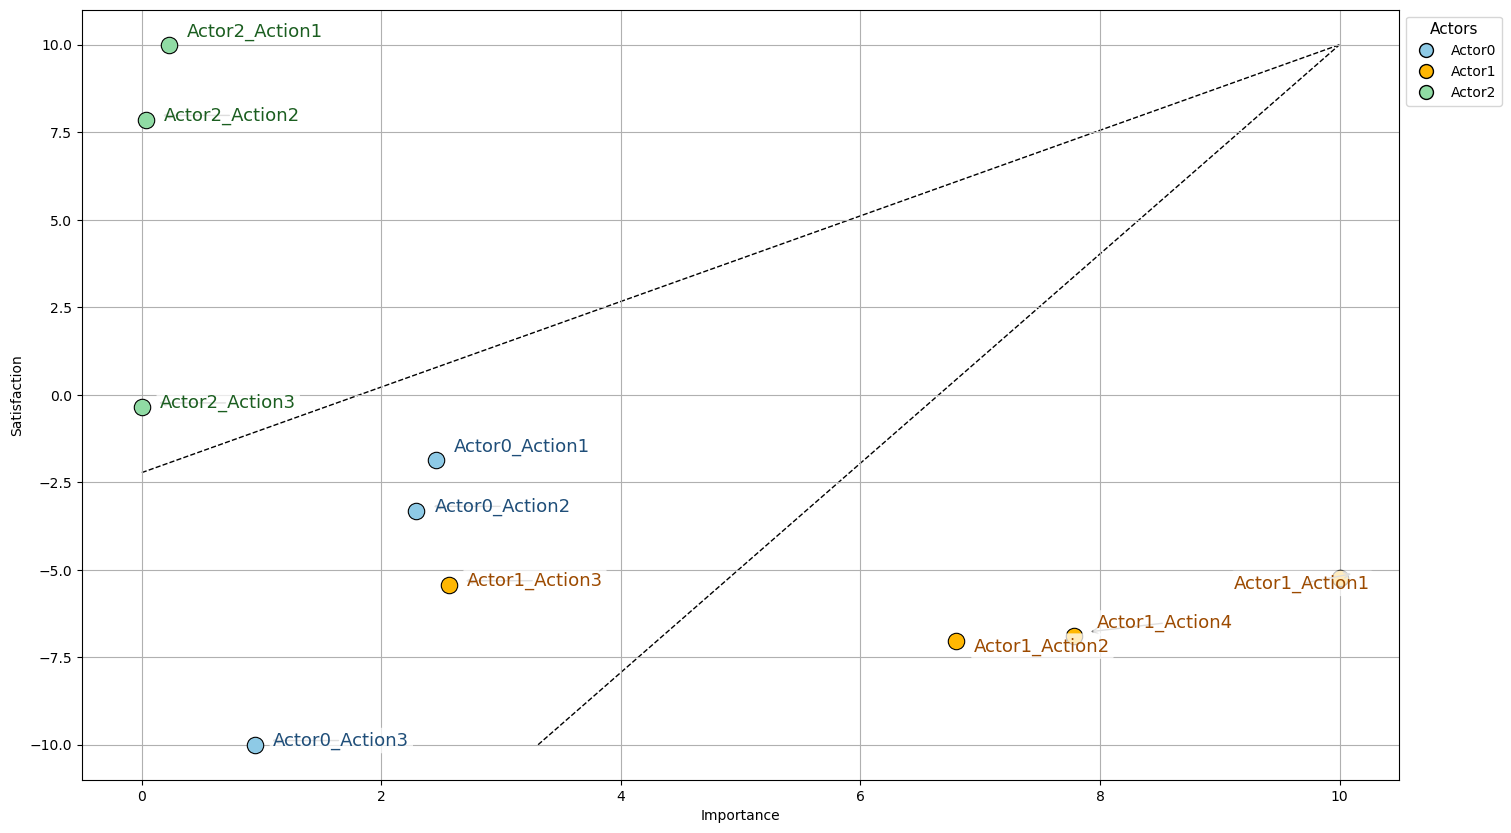

In [62]:
import re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text

plt.figure(figsize=(17, 10))

# -----------------------------
# Actor / Action 파싱
# -----------------------------
def parse_actor_action(s):
    parts = s.split("_")
    return parts[0], parts[1]

parsed = [parse_actor_action(a) for a in actions]

actors = [p[0] for p in parsed]

unique_actors = sorted(
    set(actors),
    key=lambda x: int(re.sub(r"\D", "", x))
)

# -----------------------------
# Actor별 스타일 (점 / 텍스트 분리)
# -----------------------------
actor_style = {
    "Actor0": {"point": "#8ECAE6", "text": "#1F4E79"},
    "Actor1": {"point": "#FFB703", "text": "#9C4A00"},
    "Actor2": {"point": "#90DBA4", "text": "#1B5E20"},
}

# -----------------------------
# 산점도 (점은 파스텔)
# -----------------------------
POINT_SIZE = 140

for i, (actor, action) in enumerate(parsed):
    plt.scatter(
        importance[i],
        satisfaction[i],
        s=POINT_SIZE,
        c=actor_style[actor]["point"],
        edgecolors="black",
        linewidths=0.8,
        zorder=3
    )

# -----------------------------
# 기준선 (요청 코드 유지)
# -----------------------------
# 만족도 기준선
xdata = [0, 10]
ydata = [satisfaction.mean(), 10]
plt.plot(xdata, ydata, 'k', linestyle='--', linewidth=1, zorder=1)

# 중요도 기준선
x_data = [importance.mean(), 10]
y_data = [-10, 10]
plt.plot(x_data, y_data, 'k', linestyle='--', linewidth=1, zorder=1)

# -----------------------------
# 텍스트 라벨 (점에서 떨어뜨리고 bbox 추가)
# -----------------------------
texts = []
for i, (actor, action) in enumerate(parsed):
    texts.append(
        plt.text(
            importance[i] + 0.12,            # 🔥 x offset
            satisfaction[i] + 0.12,           # 🔥 y offset
            actions[i],
            fontsize=13,
            color=actor_style[actor]["text"],
            ha="left",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
                boxstyle="round,pad=0.2"
            ),
            zorder=4
        )
    )

# 화살표 포함 자동 조정
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color="grey", lw=1),
    expand_points=(1.4, 1.4),
    expand_text=(1.2, 1.2)
)

# -----------------------------
# 범례 (Actor만)
# -----------------------------
actor_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=actor,
        markerfacecolor=actor_style[actor]["point"],
        markeredgecolor='black',
        markersize=10
    )
    for actor in unique_actors
]

plt.legend(
    handles=actor_handles,
    title="Actors",
    fontsize=10,
    title_fontsize=11,
    loc="best",
    bbox_to_anchor=(1, 1)
)

plt.xlabel("Importance")
plt.ylabel("Satisfaction")
plt.grid(True)

plt.savefig(f"{output_path}/OpportunityArea_2.png", dpi=300, bbox_inches="tight")
plt.show()
